In [118]:
import torch
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import pathlib
import seaborn as sns

from sklearn.model_selection import train_test_split
from torchvision import transforms, datasets
# from torchmetrics.classification import MulticlassAccuracy
from PIL import Image
from torchmetrics.regression import R2Score
# from torchvision import dataset
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.auto import tqdm
import random

In [119]:
path = pathlib.Path.home() / "Downloads/csiro-biomass"

train = pd.read_csv(path / "train.csv")
test = pd.read_csv(path / "test.csv")

In [120]:
train.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


In [121]:
test.head()

,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


In [122]:
train['target_name']

0       Dry_Clover_g
1         Dry_Dead_g
2        Dry_Green_g
3        Dry_Total_g
4              GDM_g
            ...     
1780    Dry_Clover_g
1781      Dry_Dead_g
1782     Dry_Green_g
1783     Dry_Total_g
1784           GDM_g
Name: target_name, Length: 1785, dtype: object

In [123]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_id      1785 non-null   object 
 1   image_path     1785 non-null   object 
 2   Sampling_Date  1785 non-null   object 
 3   State          1785 non-null   object 
 4   Species        1785 non-null   object 
 5   Pre_GSHH_NDVI  1785 non-null   float64
 6   Height_Ave_cm  1785 non-null   float64
 7   target_name    1785 non-null   object 
 8   target         1785 non-null   float64
dtypes: float64(3), object(6)
memory usage: 125.6+ KB


In [124]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sample_id    5 non-null      object
 1   image_path   5 non-null      object
 2   target_name  5 non-null      object
dtypes: object(3)
memory usage: 252.0+ bytes


In [125]:
train.describe()

,Pre_GSHH_NDVI,Height_Ave_cm,target
count,1785.000000,1785.000000,1785.000000
mean,0.657423,7.595985,24.782295
std,0.151972,10.273725,25.823738
min,0.160000,1.000000,0.000000
25%,0.560000,3.000000,4.818200
50%,0.690000,4.000000,18.200000
75%,0.770000,7.000000,35.940600
max,0.910000,70.000000,185.700000


In [126]:
# train_loader = DataLoader()

label = {label: idx for idx, label in enumerate(train["target_name"].unique())}
label

{'Dry_Clover_g': 0,
 'Dry_Dead_g': 1,
 'Dry_Green_g': 2,
 'Dry_Total_g': 3,
 'GDM_g': 4}

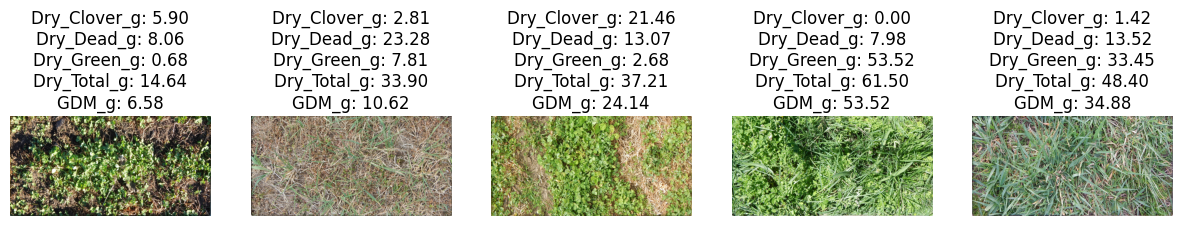

In [127]:
sample = train["image_path"].unique()
rand_image = random.sample(list(sample), 5)

# values = []

fig, axis = plt.subplots(1, len(rand_image), figsize = (15, 8))

for ax, img_path in zip(axis, rand_image):
    image = Image.open(path / img_path).convert("RGB")
    targets = train[train["image_path"] == img_path][["target_name", "target"]]
    
    # plt.figure(figsize = (5, 5))
    ax.imshow(image)
    ax.set_title("\n".join(f"{r.target_name}: {r.target:.2f}" for r in targets.itertuples()))
    # ax.set_title(targets)
    ax.axis("off")
    # ax.show()

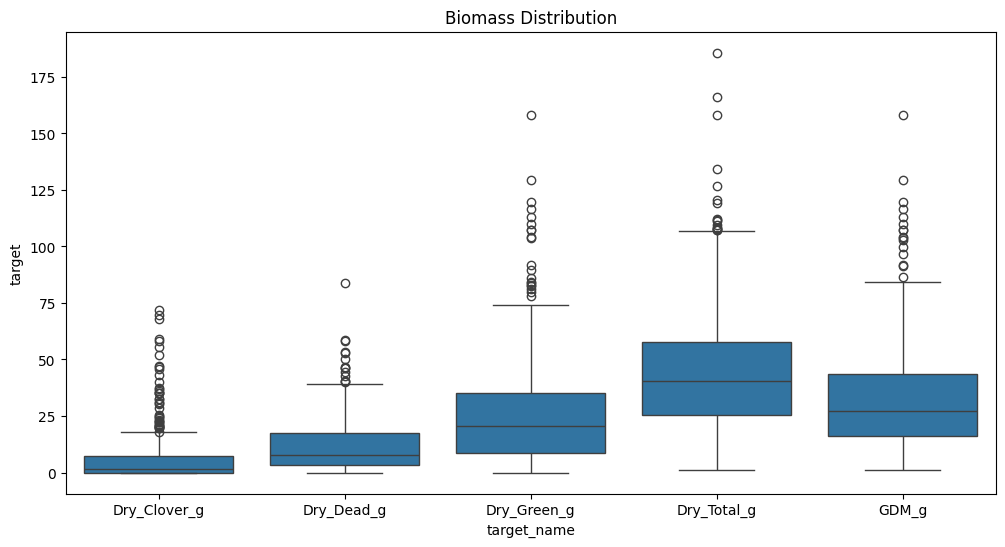

In [128]:
plt.figure(figsize=(12, 6))
sns.boxplot(train, x = "target_name", y = "target")
plt.title("Biomass Distribution")
plt.show()

In [129]:
pivot = train.pivot(index = "image_path", columns = "target_name", values = "target")
corr = pivot.corr()
corr

target_name,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
target_name,,,,,
Dry_Clover_g,1.000000,-0.175548,-0.276582,0.104185,0.204213
Dry_Dead_g,-0.175548,1.000000,0.095554,0.453912,0.012028
Dry_Green_g,-0.276582,0.095554,1.000000,0.830315,0.884257
Dry_Total_g,0.104185,0.453912,0.830315,1.000000,0.896441
GDM_g,0.204213,0.012028,0.884257,0.896441,1.000000


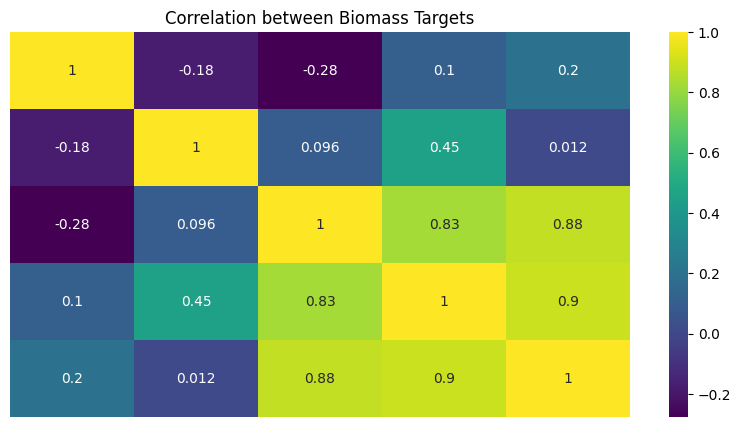

In [130]:
plt.figure(figsize = (10, 5))
sns.heatmap(corr, annot = True, cmap = "viridis")
plt.title("Correlation between Biomass Targets")
plt.axis("off")
plt.show()

<Axes: >

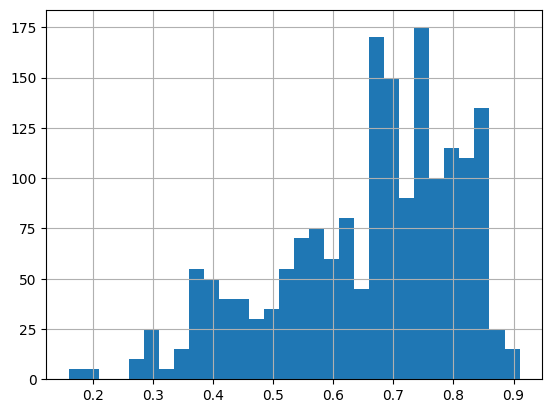

In [131]:
train["Pre_GSHH_NDVI"].hist(bins=30)

<Axes: >

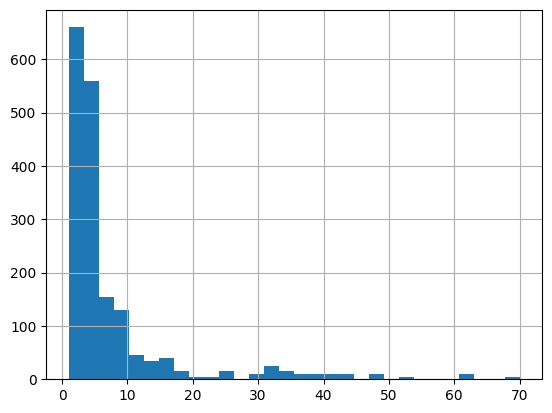

In [132]:
train["Height_Ave_cm"].hist(bins=30)

In [133]:
# label[train["target_name"]]

# lst = []

# for idx, target in enumerate(train["target_name"]):
#     ...

In [134]:
# path = pathlib.Path.home() / "Downloads/csiro-biomass" / "train/ID1463690813.jpg"

# image = Image.open(path).convert("RGB")
# path.name
# image

In [135]:
# import torch
# from torch.utils.data import Dataset, DataLoader
# import pandas as pd
# from PIL import Image
# from torchvision import transforms
# from pathlib import Path

# class BiomassDataset(Dataset):
#     def __init__(self, csv_file, transform=None):
#         super().__init__()

#         self.annotation = pd.read_csv(csv_file)
#         self.transform = transform
#         self.base_path = Path.home() / "Downloads/csiro-biomass"

#         self.label_to_idx = {label: idx for idx, label in enumerate(self.annotation["target_name"].unique())}

#     def __len__(self):
#         return len(self.annotation)

#     def __getitem__(self, idx):
#         row = self.annotation.iloc[idx]
#         image_path = self.base_path / row["image_path"]
#         label_name = row["target_name"]
#         label = self.label_to_idx[label_name]

#         image = Image.open(image_path).convert("RGB")

#         if self.transform:
#             image = self.transform(image)

#         return image, torch.tensor(label, dtype=torch.long)

In [136]:
# transform = transforms.Compose(
#     [
#         transforms.Resize((224, 224)),
#         transforms.ToTensor()
#     ]
# )

# dataset = BiomassDataset(csv_file = path / "train.csv", transform = transform)
# data_loader = DataLoader(dataset, batch_size = 32, shuffle = True)
# image, label = next(iter(data_loader))

# image.shape

In [137]:
# dataset.classes

In [138]:
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

# _traindata = datasets.ImageFolder(root = path / "train", transform = transforms)
# train_loader = DataLoader(
#     _traindata,
#     shuffle = True,
#     batchsize = 10
# )

# _testdata = datasets.ImageFolder(root = path / "test", transform = transforms)
# test_loader = DataLoader(
#     _testdata,
#     shuffle = False,
#     batch_size = 10
# )

<Axes: xlabel='image_path'>

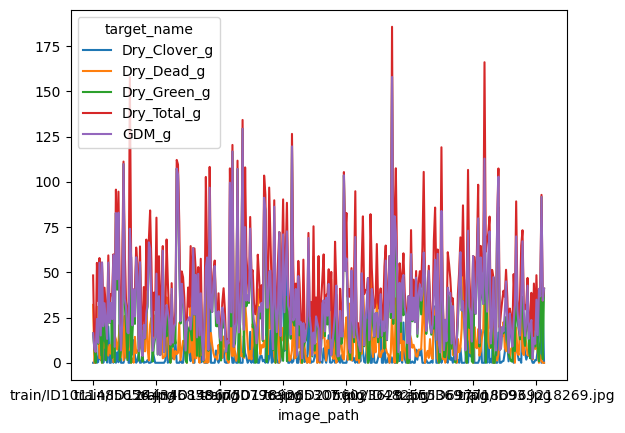

In [139]:
train.pivot_table(index = "image_path", columns = "target_name", values = "target").plot()

In [140]:
# test.pivot_table(index = "image_path", )

torch.manual_seed(42)

In [142]:
class BiomassDataset(Dataset):
    def __init__(self, csv_path, root, transform: None):
        super(BiomassDataset, self).__init__()

        self.annonation = pd.read_csv(csv_path)
        self.root = pathlib.Path(root)
        self.transform = transform

        self.grouped = (
            self.annonation
            .pivot_table(index = "image_path", columns = "target_name", values = "target")
            .reset_index()
        )
        self.target_cols = ["Dry_Clover_g", "Dry_Dead_g", "Dry_Green_g", "Dry_Total_g", "GDM_g"]

    def __len__(self):
        return len(self.grouped)

    def __getitem__(self, idx):
        rows = self.grouped.iloc[idx]
        img_path = self.root / rows["image_path"]
        image = Image.open(img_path).convert("RGB")

        # target = torch.tensor(rows[self.target_cols].values, dtype = torch.float)
        # targets = torch.from_numpy(rows[self.target_cols].values).type(torch.float32)
        # target = rows[self.target_cols].values
        target = pd.to_numeric(rows[self.target_cols], errors="coerce").astype("float32")
        target = torch.tensor(target.values, dtype=torch.float32)

        # print(type(target))

        if self.transform:
            image = self.transform(image)

        return image, target

In [143]:
class BiomassTestDataset(Dataset):
    def __init__(self, csv_path, root, transform = None):
        super(BiomassTestDataset, self).__init__()

        self.annonation = pd.read_csv(csv_path)
        self.root = pathlib.Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.annonation)

    def __getitem__(self, idx):
        rows = self.annonation.iloc[idx]
        
        img_path = self.root / rows["image_path"]
        image = Image.open(img_path).convert("RGB")

        # target = pd.to_numeric(rows["target_name"], errors = "coerce").astype("float32")
        # target = torch.tensor(target).type(torch.float32)

        target = rows["target_name"]
        sample_id = rows["sample_id"]

        # target = torch.tensor(rows["target_name"], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, target, sample_id

In [144]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [145]:
train_dataset = BiomassDataset(
    csv_path = path / "train.csv",
    root = path,
    transform = transform
)

test_dataset = BiomassTestDataset(
    csv_path = path / "test.csv",
    root = path,
    transform = transform
)

test_dataset

In [146]:
# train_loader = DataLoader(
#     train_dataset,
#     shuffle = True,
#     batch_size = 32
# )

# loader.dataset
# for image, target in ...
# for image, label in loader:
#     print(label)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

image, target = next(iter(train_loader))
image.shape, target.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32, 5]))

In [147]:
image, label = next(iter(val_loader))
image.dim()

4

In [148]:
target.unique()

tensor([  0.0000,   0.1308,   0.5000,   0.7708,   0.8024,   1.1385,   1.4353,
          1.5000,   1.6000,   1.7557,   1.9867,   2.1000,   2.3192,   2.4170,
          2.6000,   2.7000,   2.8017,   3.0000,   3.5000,   3.7000,   3.7538,
          3.8040,   3.9733,   4.1948,   4.3059,   4.5809,   5.0589,   5.3961,
          5.5597,   5.7388,   6.3000,   6.3606,   6.8000,   6.8080,   7.0000,
          7.4266,   7.6000,   7.8492,   7.8767,   7.9034,   7.9809,   8.1172,
          8.4248,   8.9400,   9.0000,   9.0220,   9.1528,   9.5934,   9.8000,
         10.1143,  10.1912,  10.5000,  10.9267,  11.6400,  12.0354,  12.0601,
         12.8377,  13.5089,  13.6615,  14.5000,  14.8000,  14.9000,  15.1400,
         15.3034,  15.3953,  15.5104,  16.3107,  16.3108,  16.3603,  16.7365,
         17.2000,  17.4426,  18.1000,  18.2154,  18.6588,  20.0941,  20.9412,
         21.0421,  21.2625,  22.0875,  22.6087,  23.1187,  23.3794,  24.4000,
         24.6445,  25.8893,  28.0478,  28.4103,  28.5594,  30.72

In [149]:
test_loader = DataLoader(test_dataset,
                        shuffle = False,
                        batch_size = 1)

len(test_loader)

5

In [150]:
image, target, sid = next(iter(test_loader))

image.shape, target

(torch.Size([1, 3, 224, 224]), ('Dry_Clover_g',))

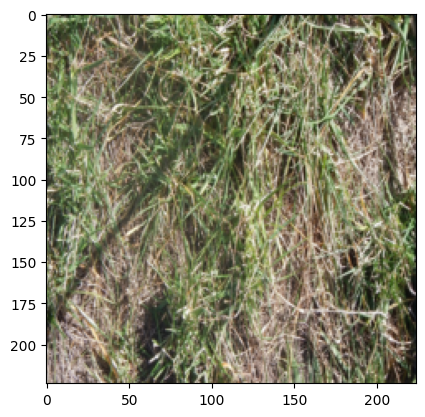

In [151]:
img = image.squeeze(0)
img = img.permute(1, 2, 0)
plt.imshow(img)

In [152]:
def r2_score_fn(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2, dim=0)
    ss_tot = torch.sum((y_true - torch.mean(y_true, dim=0)) ** 2, dim=0)
    r2 = 1 - ss_res / ss_tot
    return r2

def weighted_r2(y_true, y_pred):
    weights = torch.tensor([0.1, 0.1, 0.1, 0.5, 0.2], device=y_true.device)
    r2 = r2_score_fn(y_true, y_pred)
    final = torch.sum(weights * r2)
    return r2, final

In [106]:
class CsiroBiomassModel(torch.nn.Module):
    def __init__(self, in_features: int = 3, out_features: int = 5,
                 hidden_units: int = 128, batch_units: int = 64, drop_units: int = 32):
        super(CsiroBiomassModel, self).__init__()
        
        self.in_features: int = in_features
        self.out_featues: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_units: int = batch_units
        self.drop_units: int = drop_units
        
        self.conv_kernel_size: int = 3
        self.maxpool_kernel_size: int = 2
        self.padding: int = 1
        self.stride: int = 1
        self.p: float = 0.25

        self.convolutional_layer1: torch.nn.Sequential = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.in_features, out_channels = self.hidden_units,
                            kernel_size = self.conv_kernel_size, padding = self.padding,
                            stride = self.stride),
            torch.nn.BatchNorm2d(num_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.hidden_units, out_channels = self.hidden_units,
                            kernel_size = self.conv_kernel_size, padding = self.padding,
                            stride = self.stride),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = self.maxpool_kernel_size),
            torch.nn.Dropout2d(p = self.p)
        )

        self.convolutional_layer2: torch.nn.Sequential = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.hidden_units, out_channels = self.batch_units,
                            kernel_size = self.conv_kernel_size, padding = self.padding,
                            stride = self.stride),
            torch.nn.BatchNorm2d(num_features = self.batch_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.batch_units, out_channels = self.batch_units,
                            kernel_size = self.conv_kernel_size, padding = self.padding,
                            stride = self.stride),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = self.maxpool_kernel_size),
            torch.nn.Dropout2d(p = self.p)
        )

        self.convolutional_layer3: torch.nn.Sequential = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.batch_units, out_channels = self.drop_units,
                            kernel_size = self.conv_kernel_size, padding = self.padding,
                            stride = self.stride),
            torch.nn.BatchNorm2d(num_features = self.drop_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.drop_units, out_channels = self.drop_units,
                            kernel_size = self.conv_kernel_size, padding = self.padding,
                            stride = self.stride),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = self.maxpool_kernel_size),
            torch.nn.Dropout2d(p = self.p)
        )

        with torch.inference_mode():
            x = torch.zeros(1, self.in_features, 224, 224)
            x = self.convolutional_layer1(x)
            x = self.convolutional_layer2(x)
            x = self.convolutional_layer3(x)
            flattern = x.view(1, -1).shape[1]

        self.regression: torch.nn.Sequential = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = flattern, out_features = self.batch_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Dropout(p = self.p),
            torch.nn.Linear(in_features = self.batch_units, out_features = self.out_featues)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.convolutional_layer1(x)
        x = self.convolutional_layer2(x)
        x = self.convolutional_layer3(x)
        x = self.regression(x)
        return x

In [107]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [108]:
torch.manual_seed(42)

In [109]:
model = CsiroBiomassModel(hidden_units = 64, batch_units = 32, drop_units = 10).to(device)
model

CsiroBiomassModel(
  (convolutional_layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (convolutional_layer2): Sequential(
    (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (convolutional_layer3): Sequential(
    (0): Conv2d(32

In [110]:
image.dim()

4

In [111]:
rand_image = torch.randn(size = (1, 3, 224, 224))

result = model(rand_image.to(device))
result

tensor([[-0.1060, -0.1000, -0.1466,  0.2615,  0.2744]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [112]:
for image, label, sid in test_loader:
    print(image.shape)

torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])


In [113]:
def train_model(model: torch.nn.Module,
               criterion: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device = "cpu",
               dataset = None,
               r2score = None
    ):
    model.train()

    running_loss = 0.0
    running_r2 = 0.0
    r2score.reset()

    for idx, (image, target) in enumerate(dataset):
        target_pred = model(image.to(device))
        loss = criterion(target_pred, target.to(device))
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        # accuracy
        running_loss += loss.item()
        # running_r2 += r2score(target, target_pred).compute().item()
        r2score.update(target_pred, target.to(device))

    avg_loss = running_loss / len(dataset)
    avg_r2score = r2score.compute().item()

    print(f"Traning Loss: {avg_loss:.4f} | R2Score: {avg_r2score:.4f}")
    # print(f)

    return {
        "model": model.__class__.__name__,
        "loss": avg_loss,
        "r2score": avg_r2score
    }

In [114]:
def eval_model(model: torch.nn.Module,
              criterion: torch.nn.Module,
              dataset: Dataset,
              device: torch.device):

    model.eval()
    y_true_list, y_pred_list = [], []
    running_loss = 0.0
    running_r2score = 0.0

    with torch.inference_mode():
        for image, target in dataset:
            target_pred = model(image.to(device))
            loss = criterion(target_pred, target.to(device))

            running_loss += loss.item()
            y_true_list.append(target.to(device))
            y_pred_list.append(target_pred)

        y_true = torch.cat(y_true_list)
        y_pred = torch.cat(y_pred_list)

        avg_loss = running_loss / len(dataset)

        r2_score = r2_score_fn(y_true, y_pred).detach().cpu()
        weights = torch.tensor([0.1, 0.1, 0.1, 0.5, 0.2])
        final_r2 = torch.sum(weights * r2_score)

        print(f"Per-target R²: {r2_score} | Weighted R²: {final_r2.item()}\n")
        # print("Weighted R²:", final_r2.item())

        return {
            "model": model.__class__.__name__,
            "loss": avg_loss,
            "r2score": final_r2
        }

In [115]:
def test_model(model: torch.nn.Module,
              # criterion: torch.nn.Module,
              # optimizer: torch.optim.Optimizer,
              device: torch.device,
              dataset,
              # r2score
    ):
    model.eval()
    
    # running_loss, running_r2score = 0.0, 0.0
    # r2score.reset()

    prediction = []

    with torch.inference_mode():
        for image, target, sid in dataset:
            target_pred = model(image.to(device))
            
            # loss = criterion(target_pred, target)
            # optimizer.zero_grad()

            # loss.backward()
            # optimizer.step()
            pred = target_pred.detach().cpu().numpy()

            # for (sid, tname, p) in zip(sid, target, pred)

        #     running_loss += loss.item()
        #     r2score.update(target_pred, target)

        # avg_loss = running_loss / len(dataset)
        # avg_r2score = r2score.compute().item()

        # print(f"Testing Loss: {avg_loss:.5f} | R2Score: {avg_r2score:.5f}\n")

        return sid, target, pred

In [116]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
r2score = R2Score().to(device)

In [117]:
epochs = 10

total_epochs = []
losses = []
total_r2score = []
test_losses = []
total_test_r2score = []
prediction = []

for epoch in tqdm(range(epochs)):
    trainModel1 = train_model(model = model,
                            criterion = criterion,
                            optimizer = optimizer,
                            device = device,
                            dataset = train_loader,
                            r2score = r2score
                             )

    losses.append(trainModel1.get("loss"))
    total_r2score.append(trainModel1.get("r2score"))

    evalModel1 = eval_model(model = model,
                           criterion = criterion,
                           dataset = val_loader,
                           device = device)

    # testModel1 = test_model(model = model,
    #                         # criterion = criterion,
    #                         # optimizer = optimizer,
    #                         device = device,
    #                         dataset = test_loader,
    #                         # r2score = r2score
    #                        )

    # print(testModel1)

    # sid, target_name, pred = evalModel1
    # prediction.append({
    #     "sample_id": sid[0],
    #     "target_name": target_name[0],
    #     "pred": pred.tolist()
    # })

    total_epochs.append(epoch)

  0%|                                                    | 0/10 [00:00<?, ?it/s]

Traning Loss: 980.2094 | R2Score: -0.9589


 10%|████▍                                       | 1/10 [00:12<01:53, 12.61s/it]

Per-target R²: tensor([-0.2115, -0.9997, -1.1056, -2.6478, -1.8438]) | Weighted R²: -1.9243205785751343

Traning Loss: 599.4349 | R2Score: -0.3411


 20%|████████▊                                   | 2/10 [00:24<01:36, 12.10s/it]

...

Per-target R²: tensor([ 0.0374, -0.1038,  0.2146,  0.2488,  0.3567]) | Weighted R²: 0.21056073904037476

Traning Loss: 542.5246 | R2Score: -0.2123


 90%|███████████████████████████████████████▌    | 9/10 [01:45<00:11, 11.64s/it]

Per-target R²: tensor([ 0.0441, -0.0668,  0.1945,  0.3255,  0.3816]) | Weighted R²: 0.2562669515609741

Traning Loss: 532.3809 | R2Score: -0.1068


100%|███████████████████████████████████████████| 10/10 [01:57<00:00, 11.76s/it]

Per-target R²: tensor([ 0.0499, -0.0759,  0.2291,  0.3113,  0.3519]) | Weighted R²: 0.24636271595954895



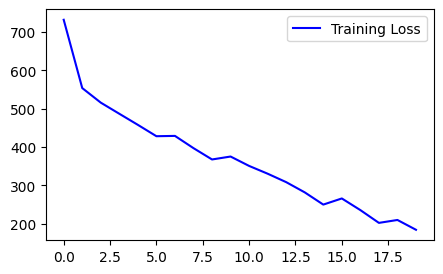

In [71]:
plt.figure(figsize=(5, 3))
plt.plot(total_epochs, losses, label = "Training Loss", c = "blue")
plt.legend()
plt.show()

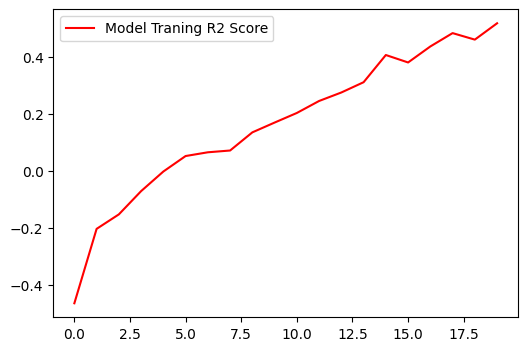

In [72]:
plt.figure(figsize=(6, 4))
plt.plot(total_epochs, total_r2score, label = "Model Traning R2 Score", c= "red")
plt.legend()
plt.show()

In [73]:
predictionDataFrame = pd.DataFrame(prediction)
predictionDataFrame.head()

""


In [76]:
rows = []
target_cols = ["Dry_Clover_g", "Dry_Dead_g", "Dry_Green_g", "Dry_Total_g", "GDM_g"]

model.eval()

with torch.inference_mode():
    for images, target_names, sample_ids in test_loader:
        preds = model(images.to(device)).cpu().numpy() 

        for sid, pred in zip(sample_ids, preds):
            for tname, value in zip(target_cols, pred):
                sample_id = f"{sid.split('__')[0]}__{tname}"
                rows.append({
                    "sample_id": sample_id,
                    "target": float(value)
                })

In [77]:
submission = pd.DataFrame(rows)
submission

,sample_id,target
0,ID1001187975__Dry_Clover_g,3.646533
1,ID1001187975__Dry_Dead_g,16.268753
2,ID1001187975__Dry_Green_g,31.296757
3,ID1001187975__Dry_Total_g,49.837639
4,ID1001187975__GDM_g,36.305618
5,ID1001187975__Dry_Clover_g,3.646533
6,ID1001187975__Dry_Dead_g,16.268753
7,ID1001187975__Dry_Green_g,31.296757
8,ID1001187975__Dry_Total_g,49.837639
9,ID1001187975__GDM_g,36.305618


In [435]:
submission.to_csv("submission.csv", index = False)

In [47]:
32 * 28 * 28

25088